<a href="https://colab.research.google.com/github/Hanaa879/Student-Performance-Analytics-System/blob/main/Student_Performance_Analytics_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title  Student Performance Analytics System & Dashboard { run: "auto" }

# We have imported these python libraries to help us analyse the data, train the model and produce a good output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder



In [2]:
#we will be connecting google drive to the Colab using code below
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/archive (2)/StudentsPerformance.csv')
# This code is to find the way to the drive for the specific file

In [4]:
# Display the first 5 rows to understand the structure
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
#So since all the ml models are in one cell we are giving a general cell to pre process the data but inside each ml model we need to go into specifics only in those sections
# Create Targets for both Classification and Regression
data['Average_Score'] = data[['math score', 'reading score', 'writing score']].mean(axis=1)
data['Performance'] = np.where(data['Average_Score'] >= 60, 1, 0)

# Target for Linear Regression (Continuous numeric marks)
y_reg = data['Average_Score']

# Target for Logistic Regression, KNN, Decision Tree, Random Forest (Binary Pass/Fail)
y = data['Performance']

# Separate features and convert text categories properly using One-Hot Encoding
# This avoids treating categorical data as arbitrary sequential numbers
X_raw = data.drop(['math score', 'reading score', 'writing score', 'Average_Score', 'Performance'], axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

# Scale features for distance-based models (KNN, K-Means, PCA)
# This prevents columns with wider ranges from dominating the algorithms
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview the ready-to-use features
print("--- Prepared Features Preview (X.head()) ---")
print(X.head())
print("-" * 44)

--- Prepared Features Preview (X.head()) ---
   gender_male  race/ethnicity_group B  race/ethnicity_group C  \
0        False                    True                   False   
1        False                   False                    True   
2        False                    True                   False   
3         True                   False                   False   
4         True                   False                    True   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False   
1                   False                   False   
2                   False                   False   
3                   False                   False   
4                   False                   False   

   parental level of education_bachelor's degree  \
0                                           True   
1                                          False   
2                                          False   
3                              

 Linear Regression → Marks Prediction Dashboard
Model trained successfully on Student Academic Features!

 METRICS:
  Mean Squared Error (MSE)   : 179.60
  Root Mean Squared Error (RMSE): 13.40 (Average grade margin error)
  R² Variance Score           : 0.16 (Model explains 16.2% of data variance)


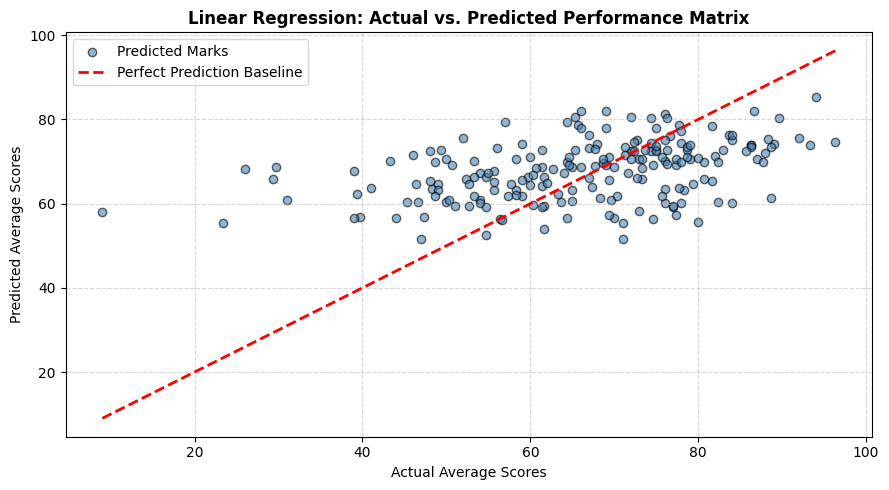

In [14]:
#@markdown Select a model from the dropdown menu to update the dashboard view.
# The code below helps us select a dashboard to display in google collabs without having to download
Select_Model = "Linear Regression" #@param ["Linear Regression", "Logistic Regression", "KNN", "Decision Tree", "Random Forest", "K-Means", "PCA"]

# DASHBOARD code
if Select_Model == "Decision Tree":
    print("Decision Tree → Academic performance analysis  ")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")

    # Train Decision Tree
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")

    # Evaluate and predict
    y_pred = model.predict(X_test)
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

    #  Plot tree visual
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=X.columns, class_names=['Fail', 'Pass'], filled=True, rounded=True, fontsize=12)
    plt.show()

    # Extract Feature Importance (This belongs ONLY to Decision Tree)
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    print("\nKey factors influencing academic performance:")
    print(feature_imp_df)

elif Select_Model == "Linear Regression":
    print(" Linear Regression → Marks Prediction Dashboard")
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score

    # 1. Split data using your continuous numeric target (y_reg is Average_Score)
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    # 2. Train the Linear Regression Model
    lr = LinearRegression()
    lr.fit(X_train_reg, y_train_reg)
    print("Model trained successfully on Student Academic Features!")

    # 3. Predict and Calculate Metrics
    y_pred_reg = lr.predict(X_test_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred_reg)

    print("\n METRICS:")
    print(f"  Mean Squared Error (MSE)   : {mse:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f} (Average grade margin error)")
    print(f"  R² Variance Score           : {r2:.2f} (Model explains {r2*100:.1f}% of data variance)")

    # 4. Generate Dashboard Comparison Plot
    plt.figure(figsize=(9, 5))
    plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, color='steelblue', edgecolors='k', label='Predicted Marks')

    # Perfect-prediction reference line
    perfect_line = [y_test_reg.min(), y_test_reg.max()]
    plt.plot(perfect_line, perfect_line, 'r--', linewidth=2, label='Perfect Prediction Baseline')

    plt.xlabel("Actual Average Scores")
    plt.ylabel("Predicted Average Scores")
    plt.title("Linear Regression: Actual vs. Predicted Performance Matrix", fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

elif Select_Model == "Logistic Regression":
    print(" Logistic Regression → Pass/Fail Prediction Dashboard")
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
    import seaborn as sns

    # 1. Split the dataset using your binary target (y is Performance: 0 for Fail, 1 for Pass)
    X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 2. Train the Logistic Regression Model
    # We use max_iter=1000 to guarantee convergence on one-hot encoded features
    lr_clf = LogisticRegression(max_iter=1000, random_state=42)
    lr_clf.fit(X_train_clf, y_train_clf)
    print("Model trained successfully on Student Academic Features!")

    # 3. Predict and Calculate Metrics
    y_pred_clf = lr_clf.predict(X_test_clf)

    print("\n METRICS:")
    print(f"  Accuracy Score: {accuracy_score(y_test_clf, y_pred_clf):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test_clf, y_pred_clf, target_names=['Fail', 'Pass'], zero_division=0))

    # 4. Generate Confusion Matrix Visualization
    cm = confusion_matrix(y_test_clf, y_pred_clf)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Fail', 'Pass'],
        yticklabels=['Fail', 'Pass']
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("Actual Labels")
    plt.title("Logistic Regression - Confusion Matrix", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

elif Select_Model == "KNN":
    print(" KNN → Similar Student Retrieval Dashboard")

    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.neighbors import NearestNeighbors
    import matplotlib.pyplot as plt

    # Prepare features
    X_knn_raw = data.copy()
    categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
    numerical_cols = ['math score', 'reading score', 'writing score']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(), categorical_cols)
        ])
    X_processed = preprocessor.fit_transform(X_knn_raw)

    # Train KNN
    knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
    knn.fit(X_processed)

    #  Define Retrieval Function with Dashboard Visuals
    def find_similar_students_dashboard(student_id, dataset, processed_data, model):
        target_student = processed_data[student_id].reshape(1, -1)
        distances, indices = model.kneighbors(target_student)

        # Extract target information
        target_info = dataset.iloc[student_id]

        # Split indices and distances to exclude the target student themselves
        similar_indices = indices[0][1:]
        similar_distances = distances[0][1:]

        # Build results dataframe
        results = dataset.iloc[similar_indices].copy()
        results.insert(0, 'Similarity Distance', similar_distances)

        # Visuals 1: Header Dashboard Panel
        from IPython.display import display, HTML
        panel_html = f"""
        <div style="background-color: #1e1e24; padding: 15px; border-radius: 8px; border-left: 5px solid #4a90e2; color: white; margin-bottom: 20px;">
            <h3 style="margin-top: 0; color: #4a90e2;"> Target Profile (Student ID: {student_id})</h3>
            <p><b>Demographics:</b> {target_info['gender'].title()} | {target_info['race/ethnicity']} | {target_info['parental level of education']}</p>
            <p><b>Scores:</b> Math: <span style="color: #ff6b6b;">{target_info['math score']}</span> | Reading: <span style="color: #4ecdc4;">{target_info['reading score']}</span> | Writing: <span style="color: #ffe66d;">{target_info['writing score']}</span></p>
        </div>
        """
        display(HTML(panel_html))

        # Visuals 2: Comparison Charts
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Chart 1: Similarity Distances (Shorter = Closer)
        y_labels = [f"Student {idx}" for idx in results.index]
        bars = ax1.barh(y_labels, results['Similarity Distance'], color='#4a90e2', alpha=0.8)
        ax1.invert_yaxis()
        ax1.set_xlabel('Distance Metric (Lower means closer peer match)')
        ax1.set_title('Match Closeness Profile', fontsize=12, fontweight='bold')
        ax1.grid(axis='x', linestyle='--', alpha=0.4)

        # Add labels to the bars
        for bar in bars:
            width = bar.get_width()
            ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
                     va='center', ha='left', fontsize=9, color='gray')

        # Chart 2: Academic Benchmark Comparison
        categories = ['Math', 'Reading', 'Writing']
        target_scores = [target_info['math score'], target_info['reading score'], target_info['writing score']]
        peer_avg_scores = [results['math score'].mean(), results['reading score'].mean(), results['writing score'].mean()]

        x_indexes = np.arange(len(categories))
        width = 0.35

        ax2.bar(x_indexes - width/2, target_scores, width=width, label=f'Target (ID {student_id})', color='#ff6b6b')
        ax2.bar(x_indexes + width/2, peer_avg_scores, width=width, label='Top 5 Peers Avg', color='#4ecdc4')

        ax2.set_xticks(x_indexes)
        ax2.set_xticklabels(categories)
        ax2.set_ylabel('Scores')
        ax2.set_title('Academic Score Comparison', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(axis='y', linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

        # Visuals 3: Peer Data Sheet
        print("\n Detailed Similar Peer Matrix:")
        return results

    # Execute Interactive Output
    sim_results = find_similar_students_dashboard(student_id=42, dataset=data, processed_data=X_processed, model=knn)
    display(sim_results)

elif Select_Model == "Random Forest":
    print(" Random Forest → Dropout prediction risk ")
    print("=" * 60)

    from sklearn.ensemble import RandomForestClassifier

    # Split Dataset
    X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train Model
    model_rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
    model_rf.fit(X_train_rf, y_train_rf)
    print("Model trained successfully!")

    # Prediction
    y_pred_rf = model_rf.predict(X_test_rf)

    print("\nAccuracy Score:", accuracy_score(y_test_rf, y_pred_rf))
    print("\nClassification Report:")
    print(classification_report(y_test_rf, y_pred_rf, target_names=["Fail", "Pass"]))

    # Feature Importance
    feature_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_rf.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print("\nTop Factors:")
    display(feature_imp.head(10))

    # Dashboard Chart
    plt.figure(figsize=(10, 6))
    plt.barh(
        feature_imp["Feature"][0:10],
        feature_imp["Importance"][0:10],
        color="teal"
    )
    plt.gca().invert_yaxis()
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()


elif Select_Model == "K-Means":
    print(" K-Means → Student Grouping & Segmentation Dashboard")
    from sklearn.cluster import KMeans
    import seaborn as sns

    #  Initialize and Fit K-Means using your globally scaled data (X_scaled)
    # This ensures features with wide scales don't dominate the clustering
    kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)

    # Assign cluster labels directly back to our original readable dataframe
    data['Cluster_Group'] = kmeans_model.fit_predict(X_scaled)
    print("K-Means clustering completed successfully on the dataset features!")

    # Analyze the Profiles of each Group dynamically
    # It calculate the mean scores for each cluster to figure out who is who
    cluster_profile = data.groupby('Cluster_Group')[['math score', 'reading score', 'writing score', 'Average_Score']].mean()

    print("\n Cluster Performance Profiles (Average Scores per Group):")
    display(cluster_profile.round(2))

    # Create a Dashboard Visual to compare the groups
    plt.figure(figsize=(10, 5))
    cluster_profile[['math score', 'reading score', 'writing score']].plot(kind='bar', figsize=(10, 6))
    plt.title('Academic Breakdown by Discovered Student Groups', fontsize=14, fontweight='bold')
    plt.xlabel('Cluster Group Label Assigned by K-Means')
    plt.ylabel('Average Academic Score')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Print a quick counts summary
    print("\nDistribution of Students across Groups:")
    print(data['Cluster_Group'].value_counts().sort_index().to_frame('Total Students'))

elif Select_Model == "PCA":
    print("  PCA → Feature Reduction & Visualization Dashboard")
    print("=" * 60)
    from sklearn.decomposition import PCA

    # 1. Initialize and Fit PCA on your pre-scaled dataset (X_scaled)
    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # 2. Print variance metric dashboard summary
    print(f"\n METRICS")
    print(f"  PC1 Variance : {pca.explained_variance_ratio_[0]:.2%}")
    print(f"  PC2 Variance : {pca.explained_variance_ratio_[1]:.2%}")
    print(f"  Total Retained Variance : {sum(pca.explained_variance_ratio_):.2%}")
    print("-" * 60)

    # 3. Component Map Plot (colored by Pass/Fail target 'y')
    plt.figure(figsize=(8, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
    plt.xlabel("Principal Component 1 (PC1)")
    plt.ylabel("Principal Component 2 (PC2)")
    plt.title("PCA - Student Data Matrix (Colored by Pass/Fail Status)", fontsize=12, fontweight='bold')
    plt.colorbar(scatter, label='0 = Fail, 1 = Pass')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

    # 4. Scree Plot (Fixed 'edgecolor' here!)
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='teal', alpha=0.8, edgecolor='k')
    plt.xlabel("Principal Component Index")
    plt.ylabel("Variance Ratio Explained")
    plt.title("PCA - Explained Variance Breakdown per Component", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()